# Router Agent

In this notebook we build a router agent that, depending on the user query, will answer differently. We use LangGraph to create a graph of how the model should behave.

## Recommended Hardware

This notebook can run on the following hardware or remote resources.

✅ AMD Instinct™ Accelerators  
✅ AMD Radeon™ RX/PRO Graphics Cards  
✅ AMD EPYC™ Processors  
✅ AMD Ryzen™ (AI) Processors  

[![Open in AMD Developer Cloud](https://img.shields.io/badge/Open_in_AMD_Developer_Cloud-000000?logo=amd&logoSize=auto)](https://amd-ai-academy.com/github/AMDResearch/aup-ai-tutorials/blob/main/ai-agents/03-mcp-router.ipynb)  

## Software Environment

Install ROCm on your system.

| Linux | Windows |
|-------|---------|
| [Install PyTorch](https://rocm.docs.amd.com/projects/install-on-linux/en/latest/install/quick-start.html) | [PyTorch on Windows](https://rocm.docs.amd.com/projects/radeon-ryzen/en/latest/docs/install/installrad/windows/install-pytorch.html)|
| [Install Docker container](https://amdresearch.github.io/aup-ai-tutorials//env/env-gpu.html) | |

## Goals

- Understand how a router agent directs queries to different personas
- Build a router agent using LangGraph with conditional edges
- Integrate MCP tools to provide real-time data within an agent
- Interact with the agent through a notebook dashboard

### Install Dependencies

Install the package dependencies needed for this notebook or series of notebooks.

First, get the `aup_config.py` script locally if needed. Then install the dependencies (`aup_setup()`). This step may take a few minutes and only needs to be done once.

In [1]:
![ -f aup_config.py ] || wget https://raw.githubusercontent.com/AMDResearch/aup-ai-tutorials/refs/heads/main/rag/aup_config.py

## Build Agent

In [2]:
# ===========================
# Smart Medicine Reminder & Health Assistant
# Step 1 : Import Libraries
# ===========================

# LangGraph
from langgraph.graph import StateGraph, START, END

# Python Utilities
from typing import TypedDict, Annotated
import operator
import re
import os

os.environ["OPENAI_API_KEY"] = "your_api_key"

# LangChain Messages
from langchain_core.messages import (
    HumanMessage,
    AIMessage,
    SystemMessage,
    AnyMessage
)

# LLM
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="llama3.1:8b",
    base_url="http://localhost:11434",
    temperature=0
)
from langgraph.graph import StateGraph
# Graph Visualization
from IPython.display import display

# Jupyter Dashboard
import ipywidgets as widgets

# Async Support
import asyncio


### Create Agent State

To manage our agent state, we create an object that can keep track of the messages. The `operator.add` makes sure that new messages are appended and not erased.

In [3]:
# ===========================
# Step 2 : Agent State
# ===========================
from typing import TypedDict
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    response: str
    category: str

### Create Medicine Assistant Agent                                                                                   

we create the MedicineAssistant class, which acts as the central controller of the Smart Medicine Reminder & Health Assistant system. This class is responsible for initializing the StateGraph, defining the different agent nodes, and establishing the workflow between them. Once the graph structure is complete, it is compiled so that it can process user requests efficiently. The language model is also initialized using a local Ollama endpoint.

The __init__() function initializes the StateGraph and registers all the specialized agents required for the application. It defines the nodes, edges, and conditional routing that control how a user's request moves through the workflow. Finally, the graph is compiled, and the language model is configured for generating responses.

`self.router` analyzes the user's query and identifies its intent. It determines whether the request is related to medicine reminders, medicine information, health guidance, or emergency assistance.
`self.router_decision` extracts the routing decision returned by the language model and directs the user's request to the appropriate specialized agent.
`self.reminder_agent` handles medication management tasks such as adding medicine reminders, checking today's schedule, identifying missed doses, and providing information about upcoming medications.
`self.medicine_agent` provides general medicine-related information, including medicine uses, dosage guidelines, side effects, precautions, and storage instructions.
`self.health_agent` offers general health and wellness guidance, such as healthy lifestyle recommendations, diet suggestions, hydration tips, and exercise advice.
`self.emergency_agent` handles emergency situations by providing immediate guidance and supporting emergency features such as SOS alerts and notifying registered family members or caregivers.

In [4]:
# ==========================================
# Step 3 : Create Medicine Assistant Agent
# ==========================================

from langchain_ollama import ChatOllama


class MedicineAssistant:

    def __init__(self, model="llama3.1:8b"):

        self.model = ChatOllama(
            model=model,
            temperature=0
        )

        graph = StateGraph(AgentState)

        graph.add_node("router", self.router)
        graph.add_node("reminder_agent", self.reminder_agent)
        graph.add_node("medicine_agent", self.medicine_agent)
        graph.add_node("health_agent", self.health_agent)
        graph.add_node("emergency_agent", self.emergency_agent)

        graph.add_edge(START, "router")

        graph.add_edge("reminder_agent", END)
        graph.add_edge("medicine_agent", END)
        graph.add_edge("health_agent", END)
        graph.add_edge("emergency_agent", END)

        graph.add_conditional_edges(
            "router",
            self.router_decision,
            {
                "reminder": "reminder_agent",
                "medicine": "medicine_agent",
                "health": "health_agent",
                "emergency": "emergency_agent",
            },
        )

        self.graph = graph.compile()


    def router(self, state: AgentState):
        return state


    def router_decision(self, state: AgentState):

        query = state["messages"][-1].lower()

        if "reminder" in query or "tablet" in query or "medicine at" in query:
            return "reminder"

        elif "side effects" in query or "drug" in query:
            return "medicine"

        elif "emergency" in query or "pain" in query:
            return "emergency"

        else:
            return "health"


    def reminder_agent(self, state: AgentState):

        query = state["messages"][-1]

        response = self.model.invoke(
            f"""
            You are a medicine reminder assistant.

            User request:
            {query}

            Give a helpful reminder response.
            """
        )

        return {
            "messages": state["messages"],
            "response": response.content,
            "category": "reminder"
        }


    def medicine_agent(self, state: AgentState):

        query = state["messages"][-1]

        response = self.model.invoke(
            f"""
            You are a medicine information assistant.

            User question:
            {query}

            Explain clearly.
            """
        )

        return {
            "messages": state["messages"],
            "response": response.content,
            "category": "medicine"
        }


    def health_agent(self, state: AgentState):

        return {
            "messages": state["messages"],
            "response": "I can help with general health guidance.",
            "category": "health"
        }


    def emergency_agent(self, state: AgentState):

        return {
            "messages": state["messages"],
            "response": "Please seek immediate medical help for emergencies.",
            "category": "emergency"
        }

### Create Router Agent

We create the `Agent` class.

1.The `router()` function inside the `MedicineAssistant`class. 
2.Receive the user's query from the `AgentState`. 
3.Analyze the user's query to understand its intent.
4.Use the Large Language Model (LLM) to classify the user's request.
5.Determine the appropriate routing category based on the user's query.
6.Route the request to one of the following specialized agents:
  . `Reminder Agent`
  . `Medicine Information Agent`
  . `Health Assistant Agent`
  . `Emergency Agent`

7.Return only the routing category without providing any explanation.
8.Pass the routing result to the next stage of the LangGraph workflow.
9.Ensure accurate and efficient request classification.
10.Serve as the entry point for all user interactions in the 
`Smart Medicine Reminder & Health Assistant` system

In [5]:
def router(self, state: AgentState):

    prompt = """
    You are a Router Agent.

    Classify the user query into only one category:

    reminder
    medicine
    health
    emergency

    Return only one word.
    """

    messages = [
        SystemMessage(content=prompt),
        state["messages"][-1]
    ]

    response = self.model.invoke(messages)

    return {
        "messages": state["messages"],
        "category": response.content.strip().lower()
    }

### Create Router Decision

The `Router Decision` method is responsible for extracting the routing category returned by the Router Agent and directing the user's request to the appropriate specialized agent. After the Router Agent analyzes the user's query and classifies it into one of the predefined categories, the Router Decision method reads the classification result and returns the corresponding routing label.

This method acts as the bridge between the `Router Agent` and the specialized agents within the LangGraph workflow. It ensures that each user request is forwarded to the correct agent based on its intent, improving the efficiency, accuracy, and organization of the Smart Medicine Reminder & Health Assistant.

In [6]:
def router_decision(self, state: AgentState):
    result = state["messages"][-1].content
    content = result.content.lower().strip()

    print("Router Output:", content)

    if "reminder" in content:
        return "reminder"
    elif "medicine" in content:
        return "medicine"
    elif "health" in content:
        return "health"
    elif "emergency" in content:
        return "emergency"

    print("No matching route found!")
    return "health"

### Create Medicine Information Agent

The `Medicine Information Agent` is responsible for providing general information about medicines within the Smart Medicine Reminder & Health Assistant. This agent answers user queries related to medicine usage, dosage guidelines, side effects, precautions, storage instructions, and other general medication information. It helps users understand their medicines better while encouraging safe medication practices.

When the Router Agent identifies that a user's request is related to medicine information, the query is forwarded to the Medicine Information Agent. The agent uses a dedicated system prompt to generate accurate, clear, and easy-to-understand responses. It provides educational information only and does not diagnose diseases or prescribe treatments.

In [7]:
def medicine_agent(state):

    user_query = state["messages"][-1]

    response = llm.invoke(
        f"""
        You are a medicine assistant.
        Answer the user's request.

        User:
        {user_query}
        """
    )

    return {
        "messages": state["messages"],
        "response": response.content,
        "category": "medicine"
    }

### Create Health Assistant Agent

1.Create the `health_agent()` method inside the MedicineAssistant class.
2.Receive health-related queries from the Router Agent.
3.Provide general health and wellness guidance.
4.Offer advice on nutrition, hydration, exercise, and sleep.
5.Encourage healthy lifestyle habits.
6.Avoid diagnosing diseases or prescribing medications.
7.Recommend consulting a healthcare professional when necessary.
8.Generate clear and supportive responses using the LLM.
9.Return the generated response to the LangGraph workflow.
10.Focus only on general health guidance and preventive care.

In [8]:
def health_agent(self, state: AgentState):
    """
    Health Assistant Agent:
    Provides general health and wellness guidance.
    """

    prompt = """
    You are the Health Assistant Agent of the Smart Medicine Reminder & Health Assistant.

    Your responsibilities include:

    - General health guidance
    - Healthy lifestyle recommendations
    - Nutrition and balanced diet advice
    - Hydration tips
    - Exercise recommendations
    - Sleep hygiene
    - Stress management
    - Preventive healthcare information

    Important Guidelines:
    - Do not diagnose diseases.
    - Do not prescribe medicines.
    - Do not replace professional medical advice.
    - Recommend consulting a qualified healthcare professional for persistent or serious health concerns.

    Provide responses that are clear, supportive, and easy to understand.
    """

    messages = [SystemMessage(content=prompt)] + state["messages"][:-1]

    response = self.model.invoke(messages)

    return {
         "messages": state["messages"],
         "response": response.content
    }

### Create Emergency Agent

The `Emergency Agent` handles emergency-related situations by providing immediate guidance and support. It responds to urgent health queries, advises users to seek medical assistance when necessary, and assists with emergency features such as SOS alerts and notifying registered family members or caregivers. This agent prioritizes user safety and encourages immediate professional medical help during critical situations.

In [9]:
def emergency_agent(self, state: AgentState):
    """
    Emergency Agent:
    Handles emergency-related queries and provides immediate guidance.
    """

    prompt = """
    You are the Emergency Agent of the Smart Medicine Reminder & Health Assistant.

    Your responsibilities include:

    - Handle emergency health situations
    - Provide immediate first-response guidance
    - Suggest calling emergency services when necessary
    - Recommend contacting a healthcare professional
    - Assist with SOS and emergency support

    Important Guidelines:
    - Stay calm and supportive.
    - Never diagnose diseases.
    - Do not prescribe medicines.
    - Advise users to seek immediate medical attention for life-threatening situations.

    Provide clear, concise, and safety-focused responses.
    """

    messages = [SystemMessage(content=prompt)] + state["messages"][:-1]

    response = self.model.invoke(messages)

    return {
         "messages": state["messages"],
         "response": response.content
    }

In [10]:
medicine_assistant = MedicineAssistant()  #Create the agent object ✅



### Create an Instance of the Medicine Assistant Agent

Creates an instance of the `MedicineAssistant` class to initialize the LangGraph workflow and enable the Smart Medicine Reminder & Health Assistant to process user queries.

In [11]:
# ==========================================
# Step 10 : Create an Instance of the Agent
# ==========================================

medicine_assistant = MedicineAssistant(model="llama3.1:8b")

### Visualize the Agent Graph

We can now visualize what our graph looks like.

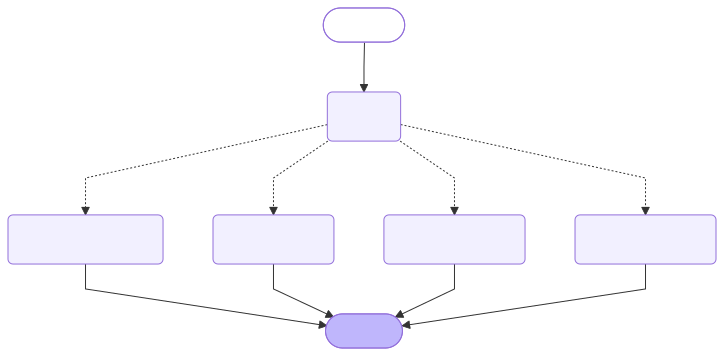

In [12]:
display(
    {
        "text/vnd.mermaid":
        medicine_assistant.graph.get_graph().draw_mermaid()
    },
    raw=True
)

In [13]:
from langgraph.graph import StateGraph

graph = StateGraph(AgentState)

graph.add_node(
    "medicine_agent",
    medicine_agent
)

graph.set_entry_point("medicine_agent")

graph.set_finish_point("medicine_agent")

### Use the Agent

Let us query the agent and try to get a story about the Mediterranean

In [14]:
graph = StateGraph(AgentState)

In [15]:
graph.add_node("medicine_agent", medicine_agent)

In [16]:
graph.set_entry_point("medicine_agent")

graph.set_finish_point("medicine_agent")

In [17]:
app = graph.compile()

In [18]:
import requests

response = requests.get("http://localhost:11434/api/tags")

print(response.json())

{'models': [{'name': 'nomic-embed-text:137m-v1.5-fp16', 'model': 'nomic-embed-text:137m-v1.5-fp16', 'modified_at': '2026-04-29T15:35:33.506914672Z', 'size': 274302450, 'digest': '0a109f422b47e3a30ba2b10eca18548e944e8a23073ee3f3e947efcf3c45e59f', 'details': {'parent_model': '', 'format': 'gguf', 'family': 'nomic-bert', 'families': ['nomic-bert'], 'parameter_size': '137M', 'quantization_level': 'F16', 'context_length': 2048, 'embedding_length': 768}, 'capabilities': ['embedding']}, {'name': 'nomic-embed-text:v1.5', 'model': 'nomic-embed-text:v1.5', 'modified_at': '2026-04-29T15:35:33.508151677Z', 'size': 274302450, 'digest': '0a109f422b47e3a30ba2b10eca18548e944e8a23073ee3f3e947efcf3c45e59f', 'details': {'parent_model': '', 'format': 'gguf', 'family': 'nomic-bert', 'families': ['nomic-bert'], 'parameter_size': '137M', 'quantization_level': 'F16', 'context_length': 2048, 'embedding_length': 768}, 'capabilities': ['embedding']}, {'name': 'nomic-embed-text:latest', 'model': 'nomic-embed-text

In [19]:
response = llm.invoke(
    "What are the side effects of Paracetamol?"
)

print(response.content)

Paracetamol (also known as acetaminophen) is a widely used over-the-counter pain reliever and fever reducer. While generally considered safe, paracetamol can cause some side effects in certain individuals or when taken in excess. Here are the possible side effects of paracetamol:

**Common side effects:**

1. **Nausea and vomiting**: Mild stomach upset is a common complaint.
2. **Diarrhea**: Some people may experience loose stools or diarrhea after taking paracetamol.
3. **Abdominal pain**: Mild to moderate stomach cramps can occur in some individuals.
4. **Dizziness**: Paracetamol can cause dizziness, especially when taken with other medications that affect the central nervous system.
5. **Headache**: Some people may experience headaches as a side effect of paracetamol.

**Less common side effects:**

1. **Allergic reactions**: Rarely, some individuals may be allergic to paracetamol and experience symptoms such as hives, itching, or difficulty breathing.
2. **Liver damage**: Taking hi

Let us query the agent and try to get a scientific response

In [20]:
assistant = MedicineAssistant()

result = assistant.graph.invoke(
    {
        "messages": [
            "I want a reminder to take my tablet at 9 PM"
        ],
        "category": "",
        "response": ""
    }
)

print(result)

{'messages': ['I want a reminder to take my tablet at 9 PM', 'I want a reminder to take my tablet at 9 PM', 'I want a reminder to take my tablet at 9 PM', 'I want a reminder to take my tablet at 9 PM'], 'response': "Here's your reminder:\n\n**Reminder: Take Your Tablet at 9 PM**\n\nDon't forget to take your medication at 9 PM tonight! Make sure to have it with you and take it as directed. If you have any questions or concerns, feel free to reach out to your healthcare provider.\n\nWould you like me to send you another reminder in the morning to help you prepare for tonight's dose?", 'category': 'reminder'}


## Agent Dashboard

The dashboard below lets you interact with the router agent directly from the notebook.

- **Type a prompt** in the text area and click **Run Agent** to send it to the agent.
- The button text changes to **Running…** while the agent processes your request.
- Once complete, the agent's **final response** is displayed automatically in the output box.
- Use the **Message slider** to browse through all intermediate messages from the latest run (e.g., the router decision, tool calls, and the final response).
- Each new run **replaces** the previous results, so you always see messages from the most recent query.

In [ ]:
!pip install gradio
import gradio as gr

# Create agent
assistant = MedicineAssistant()


def medicine_chat(user_query):

    result = assistant.graph.invoke(
        {
            "messages": [
                user_query
            ],
            "category": "",
            "response": ""
        }
    )

    return (
        result["response"],
        result["category"]
    )


# Dashboard UI

with gr.Blocks() as dashboard:

    gr.Markdown(
        """
        # 💊 Medicine Assistant Agent Dashboard
        
        AI healthcare assistant built using:
        - LangGraph
        - LangChain
        - Ollama
        - Llama 3.1 8B
        """
    )


    user_input = gr.Textbox(
        label="Ask your medicine/health question",
        placeholder="Example: What are the side effects of Paracetamol?"
    )


    submit = gr.Button("Ask AI")


    response = gr.Textbox(
        label="AI Response"
    )


    category = gr.Textbox(
        label="Agent Category"
    )


    submit.click(
        fn=medicine_chat,
        inputs=user_input,
        outputs=[response, category]
    )


dashboard.launch()

In [ ]:
assistant = MedicineAssistant()

print(assistant.model)

In [ ]:
with gr.Blocks() as dashboard:
    ...

In [ ]:
import requests

try:
    r = requests.get("http://127.0.0.1:7861")
    print(r.status_code)
    print(r.text[:100])
except Exception as e:
    print(e)

In [ ]:
dashboard.launch(
    inline=False,
    share=False,
    debug=True,
    prevent_thread_lock=True
)

In [ ]:
def predict(user_input):
    result = assistant.graph.invoke(
        {
            "messages": [user_input],
            "category": "",
            "response": ""
        }
    )

    return result["response"]

In [ ]:
demo = gr.Interface(
    fn=predict,
    inputs=gr.Textbox(
        lines=2,
        placeholder="Ask your medicine question..."
    ),
    outputs=gr.Textbox(label="Response"),
    title="💊 AI Medicine Assistant"
)

In [ ]:
print(demo)

In [ ]:
import requests

r = requests.get("http://127.0.0.1:7860")
print("Status:", r.status_code)
print(r.text[:200])

In [ ]:
from IPython.display import HTML
HTML("""
<a href="/aipc-13/user/white-silly-bee-flying/proxy/7861/" target="_blank">
Open Gradio Dashboard
</a>
""")

In [ ]:
import os

print("JUPYTERHUB_SERVICE_PREFIX =", os.environ.get("JUPYTERHUB_SERVICE_PREFIX"))
print("JUPYTERHUB_BASE_URL =", os.environ.get("JUPYTERHUB_BASE_URL"))
print("JUPYTERHUB_API_URL =", os.environ.get("JUPYTERHUB_API_URL"))

In [ ]:
demo.launch(
    server_name="0.0.0.0",
    server_port=7861,
    share=False,
    inbrowser=False
)

In [ ]:
demo.close()

## Exercises for the Reader

- Use a Reasoning model such as qwen3.5
  - Do you notice any difference in the agent answers?
- Add another path to the router where you add a different persona, e.g., historian, engineer, etc.

## Conclusions

In this notebook we built a router agent using LangGraph that directs user queries to different personas based on the content of the query. We used conditional edges in the state graph to route between a play writer and a scientist writer. We also integrated MCP tools to enrich the play writer with real-time weather data.

## References

<div class="alert alert-block alert-info">
<ul>
  <li><a href="https://docs.langchain.com/oss/python/langgraph/overview">LangGraph</a></li>
</ul>
</div>

---

[AMD University Program](https://www.amd.com/aup).

Copyright (C) 2026 Advanced Micro Devices, Inc. All rights reserved. Portions of this file consist of AI-generated content.

SPDX-License-Identifier: MIT